## Experiment: Impact of Ill-Conditioned Data on Linear Regression

This notebook uses synthetic data to show how linear regression behaves when its input features are **ill-conditioned** — that is, highly correlated with one another (multicollinearity). A model trained on ill-conditioned data is compared against an identical model trained on well-conditioned data, to see how conditioning affects the reliability of the learned coefficients.

In [1]:
import numpy as np

# Configuration
NOISE = 2
SEED = 777
DATASET_SIZE = 100
rng = np.random.default_rng(SEED)

In [2]:
# Function to estimate
def f(x: np.ndarray) -> np.ndarray:
    return x*2 + 2

## Dataset

Each dataset is generated from a known linear function with added noise, then split into a 95% training set and a 5% test set.

- **Ill-conditioned dataset.** The two input features are constructed to be almost perfectly correlated — the classic recipe for multicollinearity — which can make the estimated regression coefficients unstable.
- **Well-conditioned dataset.** The two input features are drawn independently, giving a numerically well-behaved design matrix.

Training both models on otherwise identical setups isolates the effect of feature conditioning on the learned coefficients.

In [3]:
"""Ill-Conditioned Dataset"""

# Dataset
from core.dataset import DataLoader, TensorDataset
from core.tensor import Tensor

EPS = 1e-4
SPLIT_RATIO = 0.9

x = np.linspace(-5, 5, DATASET_SIZE)
y = x + EPS * rng.standard_normal(DATASET_SIZE)

X = np.stack([x, y]).T
y = f(X)

split_idx = int(DATASET_SIZE * SPLIT_RATIO)
X_tr_ill, X_te_ill = Tensor(X[:split_idx]), Tensor(X[split_idx:])
y_tr_ill, y_te_ill = Tensor(y[:split_idx]), Tensor(y[split_idx:])

y_tr_ill += np.random.uniform(-1, 1, y_tr_ill.shape)*NOISE
y_te_ill += np.random.uniform(-1, 1, y_te_ill.shape)*NOISE

train_dataset_ill = TensorDataset(X_tr_ill, y_tr_ill)
train_dataloader_ill = DataLoader(train_dataset_ill, len(train_dataset_ill))

test_dataset_ill = TensorDataset(X_te_ill, y_te_ill)
test_dataloader_ill = DataLoader(test_dataset_ill, len(test_dataset_ill))

print(f'X.shape: {X.shape}, y.shape: {y.shape}')
print(f'X_tr.shape: {X_tr_ill.shape}, y_tr.shape: {y_tr_ill.shape}')
print(f'X_te.shape: {X_te_ill.shape}, y_te.shape: {y_te_ill.shape}')
print(f'condition number: k(X) = {np.linalg.cond(X)}')

X.shape: (100, 2), y.shape: (100, 2)
X_tr.shape: (90, 2), y_tr.shape: (90, 2)
X_te.shape: (10, 2), y_te.shape: (10, 2)
condition number: k(X) = 53974.78736231793


In [4]:
"""Well-Conditioned Dataset"""

# Dataset
from core.dataset import DataLoader, TensorDataset
from core.tensor import Tensor

x = rng.uniform(-5, 5, DATASET_SIZE)
y = rng.uniform(-5, 5, DATASET_SIZE)

X = np.stack([x, y]).T
y = f(X)

split_idx = int(DATASET_SIZE * SPLIT_RATIO)
X_tr_well, X_te_well = Tensor(X[:split_idx]), Tensor(X[split_idx:])
y_tr_well, y_te_well = Tensor(y[:split_idx]), Tensor(y[split_idx:])

y_tr_well += rng.uniform(-1, 1, y_tr_well.shape)*NOISE
y_te_well += rng.uniform(-1, 1, y_te_well.shape)*NOISE

train_dataset_well = TensorDataset(X_tr_well, y_tr_well)
train_dataloader_well = DataLoader(train_dataset_well, len(train_dataset_well))

test_dataset_well = TensorDataset(X_te_well, y_te_well)
test_dataloader_well = DataLoader(test_dataset_well, len(test_dataset_well))

print(f'X.shape: {X.shape}, y.shape: {y.shape}')
print(f'X_tr.shape: {X_tr_well.shape}, y_tr.shape: {y_tr_well.shape}')
print(f'X_te.shape: {X_te_well.shape}, y_te.shape: {y_te_well.shape}')
print(f'condition number: k(X) = {np.linalg.cond(X)}')

X.shape: (100, 2), y.shape: (100, 2)
X_tr.shape: (90, 2), y_tr.shape: (90, 2)
X_te.shape: (10, 2), y_te.shape: (10, 2)
condition number: k(X) = 1.069438902750966


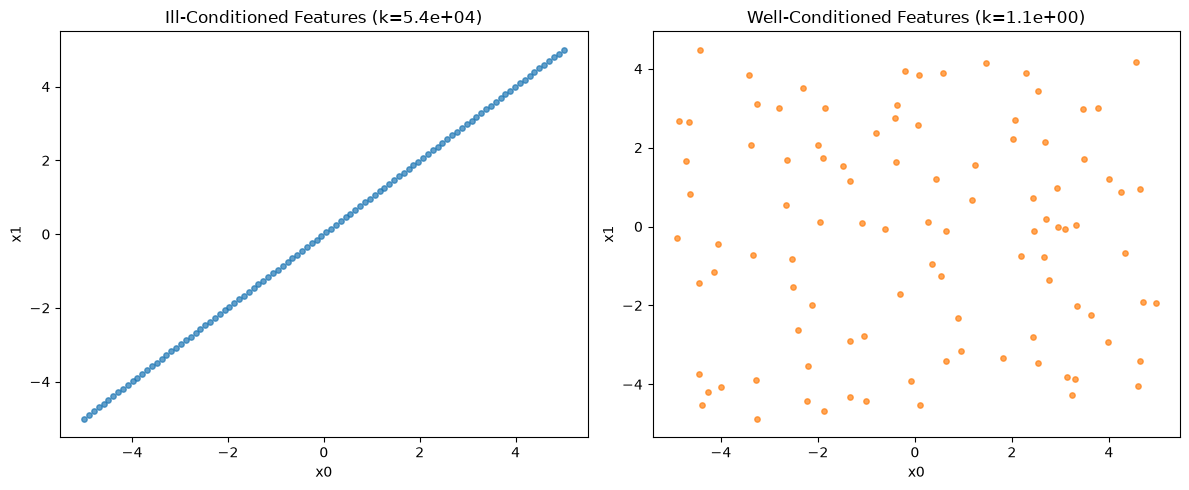

In [5]:
"""Feature correlation: ill vs well conditioned"""

import matplotlib.pyplot as plt

X_ill_full = np.vstack([X_tr_ill.data, X_te_ill.data])
X_well_full = np.vstack([X_tr_well.data, X_te_well.data])

fig, (ax_feat_ill, ax_feat_well) = plt.subplots(1, 2, figsize=(12, 5))

ax_feat_ill.scatter(X_ill_full[:, 0], X_ill_full[:, 1], s=15, alpha=0.7)
ax_feat_ill.set_title(f"Ill-Conditioned Features (k={np.linalg.cond(X_ill_full):.1e})")
ax_feat_ill.set_xlabel("x0")
ax_feat_ill.set_ylabel("x1")

ax_feat_well.scatter(X_well_full[:, 0], X_well_full[:, 1], s=15, alpha=0.7, color='C1')
ax_feat_well.set_title(f"Well-Conditioned Features (k={np.linalg.cond(X_well_full):.1e})")
ax_feat_well.set_xlabel("x0")
ax_feat_well.set_ylabel("x1")

fig.tight_layout()
plt.show()

In [6]:
from core.optimizer import SGD
from core.losses import MSELoss
from core.layers import Linear, Sequential
from core.training import Trainer

LR = 1e-4

# Linear Regression
model_ill = Sequential(
    Linear(2, 2)
)
model_well = Sequential(
    Linear(2, 2)
)
loss_ill = MSELoss()
loss_well = MSELoss()
optimizer_ill = SGD(model_ill.parameters, LR)
optimizer_well = SGD(model_well.parameters, LR)

trainer_ill = Trainer(model_ill, loss_ill, optimizer_ill)
trainer_well = Trainer(model_well, loss_well, optimizer_well)

In [7]:
"""Training loop configuration"""

LR = 1e-4
EPOCHS = 2500
EVAL_STEP = 5

In [8]:
"""Training loop: ill-conditioned dataset"""

for i, epoch in enumerate(range(EPOCHS)):
    _ = trainer_ill.train_epoch(train_dataloader_ill, 1)

    if i % EVAL_STEP == 0:
        _ = trainer_ill.eval(test_dataloader_ill)

In [9]:
"""Training loop: well-conditioned dataset"""

for i, epoch in enumerate(range(EPOCHS)):
    _ = trainer_well.train_epoch(train_dataloader_well, 1)

    if i % EVAL_STEP == 0:
        _ = trainer_well.eval(test_dataloader_well)

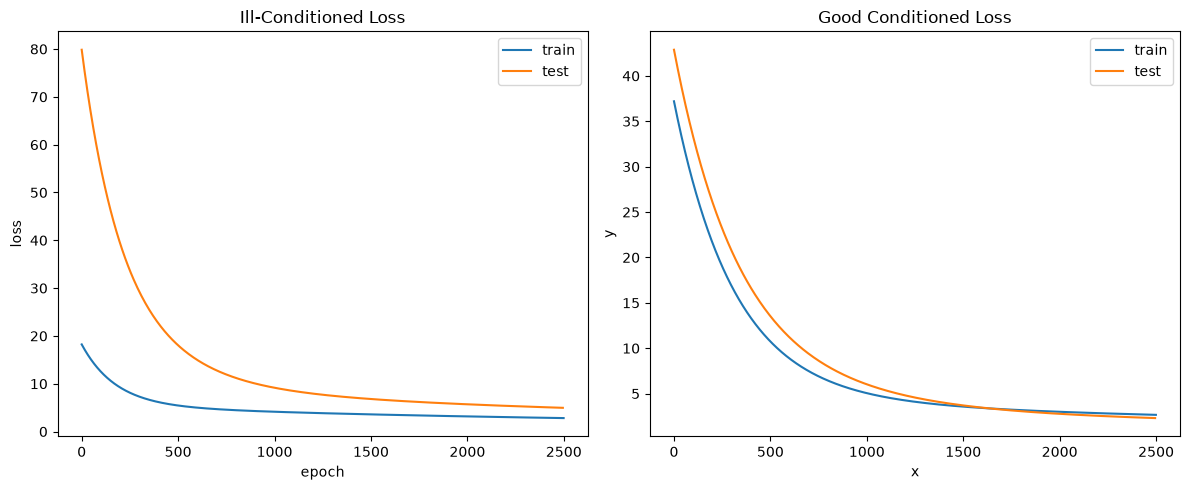

In [10]:
import matplotlib.pyplot as plt

# Loss section

# Plot in one window, divided into sections
fig, (ax_loss_ill, ax_loss_well) = plt.subplots(1, 2, figsize=(12, 5))

# Loss section
ax_loss_ill.plot(list(range(EPOCHS)), trainer_ill.train_loss, label="train")
ax_loss_ill.plot(list(range(0, EPOCHS, EVAL_STEP)), trainer_ill.eval_loss, label="test")
ax_loss_ill.set_title("Ill-Conditioned Loss")
ax_loss_ill.set_xlabel("epoch")
ax_loss_ill.set_ylabel("loss")
ax_loss_ill.legend()

# Result section (the regression)
ax_loss_well.plot(list(range(EPOCHS)), trainer_well.train_loss, label='train')
ax_loss_well.plot(list(range(0, EPOCHS, EVAL_STEP)), trainer_well.eval_loss, label='test')
ax_loss_well.set_title("Good Conditioned Loss")
ax_loss_well.set_xlabel("x")
ax_loss_well.set_ylabel("y")
ax_loss_well.legend()

fig.tight_layout()
plt.show()

In [11]:
"""Ill-Conditioned Dataset"""

# Closed form solution
from core.functions import mse


A = np.hstack([X_te_ill.data, np.ones((X_te_ill.shape[0], 1))])
coefs, *_ = np.linalg.lstsq(A, y_te_ill.data, rcond=None)
closed_form = A @ coefs

# Prediction
pred = model_ill(X_te_ill)
W_model, b_model = model_ill.parameters[:]
W_model, b_model = W_model.data, b_model.data.reshape(-1, 1)
params = np.hstack([W_model, b_model]).T

pred_residual = mse(pred.data, closed_form)
weights_residual = mse(params, coefs)

print('RESULTS OF ILL-CONDITIONED DATA\n\n')
print(f'prediction residual: {pred_residual}')
print(f'weights resididual: {weights_residual}\n')
print(f'model params:\n {params}\n')
print(f'closed form coefficent:\n {coefs}')

params_ill = params.copy()
coefs_ill = coefs.copy()

RESULTS OF ILL-CONDITIONED DATA


prediction residual: 3.6155391827066743
weights resididual: 1793630.083507458

model params:
 [[1.2524002  0.60453933]
 [1.0036333  0.9150448 ]
 [0.7240823  0.79238933]]

closed form coefficent:
 [[-2.31725798e+03  9.46954031e+01]
 [ 2.31803525e+03 -9.26291242e+01]
 [ 7.80518728e+00  1.72758247e+00]]


## Considerations

As the results show, the prediction residual — `mse(pred, closed_form)` — stays fairly low, but the weights residual — `mse(w, closed_form_w)` — is enormous by comparison. In other words, the model's predictions closely match the closed-form solution, yet its coefficients do not. This gap is a clear symptom of ill-conditioned data: the model can fit the data well without recovering coefficients that are meaningful or stable.

In [12]:
"""Well-Conditioned Dataset"""

# Closed form solution
from core.functions import mse


A = np.hstack([X_te_well.data, np.ones((X_te_well.shape[0], 1))])
coefs, *_ = np.linalg.lstsq(A, y_te_well.data, rcond=None)
closed_form = A @ coefs

# Prediction
pred = model_well(X_te_well)
W_model, b_model = model_well.parameters[:]
W_model, b_model = W_model.data, b_model.data.reshape(-1, 1)
params = np.hstack([W_model, b_model]).T

pred_residual = mse(pred.data, closed_form)
weights_residual = mse(params, coefs)

print('RESULTS OF WELL-CONDITIONED DATA\n\n')
print(f'prediction residual: {pred_residual}')
print(f'weights resididual: {weights_residual}\n')
print(f'model params:\n {params}\n')
print(f'closed form coefficent:\n {coefs}')

params_well = params.copy()
coefs_well = coefs.copy()

RESULTS OF WELL-CONDITIONED DATA


prediction residual: 1.559347453132442
weights resididual: 0.42617645631972706

model params:
 [[ 1.8332778  -0.0679551 ]
 [ 0.01216174  1.8358905 ]
 [ 0.68193656  0.6773152 ]]

closed form coefficent:
 [[ 2.22701483  0.03570634]
 [-0.21560467  1.98612898]
 [ 1.95526082  1.51126987]]


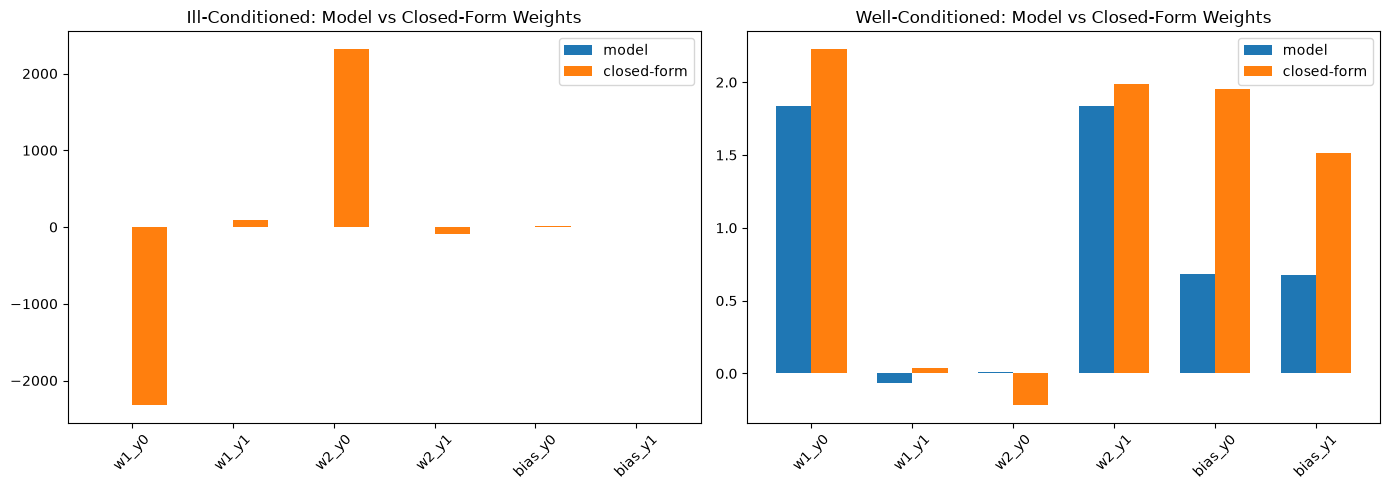

In [13]:
"""Weights comparison: model vs closed-form"""

labels = ['w1_y0', 'w1_y1', 'w2_y0', 'w2_y1', 'bias_y0', 'bias_y1']
x = np.arange(len(labels))
width = 0.35

fig, (ax_w_ill, ax_w_well) = plt.subplots(1, 2, figsize=(14, 5))

ax_w_ill.bar(x - width/2, params_ill.flatten(), width, label='model')
ax_w_ill.bar(x + width/2, coefs_ill.flatten(), width, label='closed-form')
ax_w_ill.set_title("Ill-Conditioned: Model vs Closed-Form Weights")
ax_w_ill.set_xticks(x)
ax_w_ill.set_xticklabels(labels, rotation=45)
ax_w_ill.legend()

ax_w_well.bar(x - width/2, params_well.flatten(), width, label='model')
ax_w_well.bar(x + width/2, coefs_well.flatten(), width, label='closed-form')
ax_w_well.set_title("Well-Conditioned: Model vs Closed-Form Weights")
ax_w_well.set_xticks(x)
ax_w_well.set_xticklabels(labels, rotation=45)
ax_w_well.legend()

fig.tight_layout()
plt.show()

# Conclusion

This experiment demonstrates the impact of ill-conditioned data on linear regression. A high condition number in the input features does not necessarily hurt predictive accuracy, but it does make the estimated coefficients unstable and unreliable: different runs, or a slightly different sample of the data, can produce very different weights while still fitting the data equally well.

### Why it matters

- In production, collinearity is breakable for any reason — sensor outage, or simply the condition changes. A model that seemed to rely on stable, interpretable coefficients can see those coefficients swing wildly once the correlation between features that held during training no longer holds at inference time.

- Whenever the learned coefficients themselves need to be interpreted, not just used for prediction — it's worth checking the conditioning of your input features before trusting what a model has "learned" about them.